15 December 2025

##### Prerequisites

In [1]:
# Import libraries
import numpy as np 
import matplotlib.pyplot as plt
import scipy, pickle
import scipy.signal
from tqdm import tqdm
from scipy import ndimage


In [2]:
# Constants
epsilon = 1e-10

#### Supporting Functions

##### Data extraction

In [3]:
def get_input_data(activation_path, trajectory_path):
    with open(trajectory_path, 'rb') as f:
        data_pos = pickle.load(f)

    with open(activation_path, 'rb') as f:
        activations = pickle.load(f)

    #data_pos['x'][0],data_pos['x'][0] = -0.7,-0.7
    x = np.asarray(data_pos['x'])
    y = np.asarray(data_pos['y'])
    positions = np.column_stack((x, y))
    return positions, activations

##### Plotting functions

In [4]:
def plot_activations_vs_position(activations, positions, layer_name):
    """
    Plots neuron activations for each layer against position.

    Parameters:
    activations: list of tensors containing neuron activations for specific layer
    positions: numpy array of shape (time_steps, 1), containing positions at each timestep
    """

    x_axis = positions[:, 0]

    num_neurons = activations.shape[1]
    #num_neurons = 1

    num_rows = 10
    num_cols = 5

    plt.figure(figsize=(20, 2 * num_rows))
    plt.suptitle(f'Amplitude vs Position for Layer: {layer_name}', fontsize=16)

    for neuron_index in range(num_neurons):
        plt.subplot(num_rows, num_cols, neuron_index + 1)
        plt.plot(x_axis, activations[:, neuron_index], color = "green")
        #plt.plot(x_axis_rest, activations[500:1000, neuron_index], color = "red")
        #plt.plot(x_axis_backward, activations[1000:1500, neuron_index], color = "orange")
        plt.xlabel('Position')
        plt.ylabel('Amplitude')
        plt.title(f'Neuron {neuron_index + 1}')
        #plt.ylim(global_min, global_max)  # Adjust as per the range of activation values

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frm_vs_position_2d(frm_list, positions, layer_name, xedges, yedges, res_param=40, cmap='jet'):
    """
    Plots 2D firing-rate maps for all neurons in a given layer.

    Parameters
    ----------
    frm_list : list or np.ndarray
        List of 2D firing rate maps (one per neuron)
    positions : np.ndarray
        (T, 2) array of (x, y) positions
    layer_name : str
        Name of the layer (for title)
    xedges, yedges : np.ndarray
        Bin edges from occupancy map (used for extent)
    res_param : int
        Resolution parameter used for histogram binning
    cmap : str
        Colormap for visualization
    """
    num_neurons = len(frm_list)

    # Subplot layout
    num_rows = 10
    num_cols = 10
    total_plots = num_rows * num_cols
    if num_neurons < total_plots:
        num_rows = int(np.ceil(num_neurons / num_cols))

    plt.figure(figsize=(3 * num_cols, 3 * num_rows))
    plt.suptitle(f"Firing Rate Maps — Layer: {layer_name}", fontsize=16)

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    for neuron_index in range(num_neurons):
        plt.subplot(num_rows, num_cols, neuron_index + 1)

        # Convert each map to float array safely
        fr_map = np.array(frm_list[neuron_index], dtype=float)

        # Mask NaNs for clean visualization
        fr_map_plot = np.copy(fr_map)
        fr_map_plot[np.isnan(fr_map_plot)] = 0

        # Plot heatmap
        plt.imshow(np.rot90(fr_map_plot), origin='lower', cmap=cmap, extent=extent)
        plt.title(f"Neuron {neuron_index + 1}")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


##### Maps

In [6]:
import numpy as np
import scipy.signal

def occupancy_map_func_2d(pos, reso=40, win_len=9, sigma=3.0):
    """
    2D Occupancy Map to get spatial occupancy probability P(x, y).

    Parameters:
    ------------
    pos : np.ndarray
        (T, 2) array of positions [x, y]
    reso : int
        Resolution for the histogram (bins per axis = reso*2)
    win_len : int
        Window size for the Gaussian filter (should be odd)
    sigma : float
        Standard deviation for Gaussian kernel (controls smoothing)

    Returns:
    --------
    pos_prob : 2D np.ndarray
        Smoothed occupancy probability map normalized to sum=1
    xedges, yedges : np.ndarray
        Bin edges along X and Y
    """

    # --- Extract x and y positions ---
    x = pos[:, 0]
    y = pos[:, 1]

    # --- 2D histogram ---
    H, xedges, yedges = np.histogram2d(x, y, bins=(reso * 2, reso * 2))

    # --- Create 2D Gaussian filter ---
    ax = np.linspace(-3, 3, win_len)
    gauss_1d = np.exp(-0.5 * (ax / sigma) ** 2)
    gauss_2d = np.outer(gauss_1d, gauss_1d)
    gauss_2d /= np.sum(gauss_2d)

    # --- Smooth occupancy map ---
    H_smooth = scipy.signal.convolve2d(H, gauss_2d, mode='same', boundary='fill', fillvalue=0)

    # --- Normalize to get probability map ---
    pos_prob = H_smooth / np.nansum(H_smooth)
    pos_prob[pos_prob == 0] = np.nan  # for visualization clarity

    return pos_prob, xedges, yedges


In [ ]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

def firing_rate_map_2d(resp_neurons, positions, occupancy_map, thresh_param=0.0,
                       title="", ticks_colbar=None, res_param=40, sub_plot=False):
    """
    Compute 2D firing-rate map from neuron activations and position data.

    Parameters
    ----------
    resp_neurons : np.ndarray
        (T,) activations (response of one neuron)
    positions : np.ndarray
        (T, 2) array of positions [x, y]
    occupancy_map : 2D np.ndarray
        Smoothed occupancy probability map (e.g., from occupancy_map_func_2d)
    thresh_param : float
        Threshold multiplier -> mean + thresh_param * std for selecting spikes
    title : str
        Plot title
    ticks_colbar : list or None
        Colorbar ticks
    res_param : int
        Resolution (number of bins per axis = res_param*2)
    sub_plot : bool
        If False → show individual plot

    Returns
    -------
    firingmap_smooth : 2D np.ndarray
        Smoothed firing rate map (normalized by occupancy)
    firingmap_norm : 2D np.ndarray
        Normalized (0–1) map for visualization
    spike_positions : np.ndarray
        Positions where neuron exceeded threshold
    """

    # -------------------------------
    # Step 1: Compute firing threshold
    # -------------------------------
    mean_resp = np.mean(resp_neurons)
    std_resp = np.std(resp_neurons)
    thresh = mean_resp + thresh_param * std_resp

    # -------------------------------
    # Step 2: Select "spike" positions
    # -------------------------------
    active_idx = np.where(resp_neurons > thresh)[0]
    spike_positions = positions[active_idx]

    # -------------------------------
    # Step 3: Create 2D histogram grid
    # -------------------------------
    x = positions[:, 0]
    y = positions[:, 1]
    bins = (res_param * 2, res_param * 2)

    if len(spike_positions) > 0:
        # Spike-count histogram
        H_spike, xedges, yedges = np.histogram2d(spike_positions[:, 0],
                                                 spike_positions[:, 1],
                                                 bins=bins, weights=amplitude)
    else:
        H_spike, xedges, yedges = np.zeros_like(occupancy_map), None, None

    # -------------------------------
    # Step 4: Normalize by occupancy
    # -------------------------------
    # Scale occupancy map to same shape as spike histogram
    occ_resized = occupancy_map
    occ_resized = np.where(occ_resized == 0, np.nan, occ_resized)

    firingmap = H_spike / (occ_resized + 1e-10)

    # -------------------------------
    # Step 5: Apply 2D Gaussian smoothing
    # -------------------------------
    win_len = 9
    ax = np.linspace(-3, 3, win_len)
    gauss_1d = np.exp(-0.5 * (ax ** 2))
    gauss_2d = np.outer(gauss_1d, gauss_1d)
    gauss_2d /= np.sum(gauss_2d)

    firingmap_smooth = scipy.signal.convolve2d(firingmap, gauss_2d,
                                               mode='same', boundary='fill', fillvalue=0)

    # -------------------------------
    # Step 6: Normalize 0–1 for visualization
    # -------------------------------
    finite_vals = firingmap_smooth[np.isfinite(firingmap_smooth)]
    if len(finite_vals) > 0:
        firingmap_norm = (firingmap_smooth - finite_vals.min()) / (finite_vals.max() - finite_vals.min() + 1e-10)
    else:
        firingmap_norm = firingmap_smooth

    # -------------------------------
    # Step 7: Plot
    # -------------------------------
    if not sub_plot:
        plt.figure(figsize=(5, 5))
        plt.imshow(np.rot90(firingmap_smooth), origin='lower', cmap='jet')
        plt.title(title)
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.colorbar(ticks=ticks_colbar)
        plt.show()

    return firingmap_smooth, firingmap_norm, spike_positions


In [9]:
print(trajectory_results[0].keys())

NameError: name 'trajectory_results' is not defined

##### Scores

In [11]:
def inf_rate(rate_map, px):
    '''
    Calculating spatial information rate - bytes/ spike
    rate_map: firing rate map
    px: occupancy map
    '''
    tmp_map = np.ma.array(rate_map, copy=True)
    tmp_map[np.isnan(tmp_map)] = 0
    avg_rate = np.sum(np.ravel(tmp_map * px))

    #return (np.nansum(np.ravel(tmp_map * np.log2(tmp_map/avg_rate) * px)),
    #        avg_rate)

    return (np.nansum(np.ravel((tmp_map/avg_rate) * np.log2(np.maximum(tmp_map/avg_rate, epsilon)) * px)),
            avg_rate)

In [12]:
def sparsity_func(pos_prob, firing_rate):
    '''
    Calculating sparsity for a given firing rate map

    input:
    pos_prob: probability matrix for position - from occupancy map
    firing_rate: rate map

    output: sparsity from the paper
    '''
    px = np.copy(pos_prob)
    pos_prob2 = px/(np.nansum(px) + epsilon)

    avg_rate = np.nansum(np.ravel(firing_rate * pos_prob2))
    numerator = avg_rate ** 2
    denominator = np.nansum(np.multiply(pos_prob2, firing_rate**2)) + epsilon
    return numerator/denominator

In [13]:
def get_scores(positions, activations):
    '''
    Calculating sparsity,  spatial information rate and spatial score
    '''

    global lim, reso
    sparsity_scores = []
    spatial_info = []
    occupancy_map = occupancy_map_func(positions)
    num_neurons = activations.shape[1]
    fpg_allN = []
    fm_allN = []
    for i in range(num_neurons):
        resp_neurons = activations[:, i]

        fr_map, fr_norm, firposgrid = firing_rate_map(resp_neurons, positions, occupancy_map=occupancy_map, thresh_param=lim, res_param = reso, sub_plot=True)
        fm_allN.append(fr_norm)
        fpg_allN.append(firposgrid)
        # Calculating spatial info
        sp_info_rate, avg_rate = inf_rate(fr_map, occupancy_map)
        #spatial_information = sp_info_rate*0.1/avg_rate
        spatial_information = sp_info_rate/avg_rate
        if np.ma.is_masked(spatial_information):
            spatial_information = 0  # Replace masked value with 0 or any other default value you prefer
        else:
            spatial_information = round(spatial_information,2)
        spatial_info.append(spatial_information)


        # Calculating sparsity scores
        sparsity_score = sparsity_func(occupancy_map, fr_map)
        if np.ma.is_masked(sparsity_score):
            sparsity_score = 0  # Replace masked value with 0 or any other default value you prefer
        else:
            sparsity_score = round(sparsity_score,2)
        sparsity_scores.append(sparsity_score)

    return spatial_info, sparsity_scores, fpg_allN, fm_allN

In [27]:
def plot_frm_vs_position_single(frm, positions, layer_name, res_param=40):
    """
    Plots firing rate maps of all neurons in a single plot vs position.
    """
    positions = np.array(positions)  # Ensure it's a NumPy array
    x = np.linspace(positions.min(), positions.max(), frm.shape[1])
    num_neurons = frm.shape[0]

    plt.figure(figsize=(10, 6))
    for neuron_index in range(num_neurons):
        plt.plot(x, frm[neuron_index], label=f'Neuron {neuron_index + 1}', alpha=0.7)

    plt.title(f'Firing Rate vs. Position — Layer: {layer_name}', fontsize=14)
    plt.xlabel('Position')
    plt.ylabel('Firing Rate')
    if num_neurons <= 20:
        plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


##### Extracting place cells

In [28]:
def identify_place_cells(spatial_info, sparsity_scores, positions, activations):


    selected_neus_spainfo = np.where(np.asarray(spatial_info) > spi_threshold)[0]
    print(f"Neurons selected wrt spatial_info: ", selected_neus_spainfo)

    selected_neus_spars = np.where(np.asarray(sparsity_scores) < spar_threshold)[0]
    print(f"Neurons selected wrt to sparsity: ", selected_neus_spars)

    selected_neus = list(set(selected_neus_spars) & set(selected_neus_spainfo))
    print(f"Neurons satisfying both criteria: ", np.array(selected_neus))

    place_cells = selected_neus

    return place_cells


In [29]:
def get_scores_by_place_cells(place_cells, spatial_info, sparsity_scores):
    '''
    Extracts spatial information and sparsity scores for identified place cells.

    Args:
        place_cells (list): A list of indices representing the identified place cells.
        spatial_info (list): A list of spatial information scores for all neurons.
        sparsity_scores (list): A list of sparsity scores for all neurons.

    Returns:
        dict: A dictionary containing the place cell indices, spatial information scores,
              and sparsity scores for the selected place cells.
    '''

    place_cells_indices = []
    place_cells_spatial = []
    place_cells_sparsity = []

    for i in place_cells:
        place_cells_indices.append(i)  # Corrected indexing
        place_cells_spatial.append(spatial_info[i])  # Corrected indexing
        place_cells_sparsity.append(sparsity_scores[i])  # Corrected indexing

    pc_dict = {
        'place_cells_indices': place_cells_indices,
        'spatial_info': place_cells_spatial,
        'sparsity_scores': place_cells_sparsity
    }

    return pc_dict


### Identifying place cells

#### Input data extraction

In [ ]:
import pickle

trajectory_path = "/Users/ais/Desktop/2026_Summer/2D-place-grid-cells/2D-traj-results.pkl"

with open(trajectory_path, "rb") as f:
    traj_data = pickle.load(f)
print(type(traj_data))
print(traj_data.keys())


<class 'dict'>
dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3'])


In [18]:
for key, value in traj_data.items():
    print(f"{key}:")
    print(type(value))

    if hasattr(value, "shape"):
        print("Shape:", value.shape)

    elif isinstance(value, list):
        print("Length:", len(value))
        if len(value) > 0:
            print("First element type:", type(value[0]))

    print()

time:
<class 'numpy.ndarray'>
Shape: (500,)

ground_truth:
<class 'numpy.ndarray'>
Shape: (50, 500, 2)

prediction:
<class 'numpy.ndarray'>
Shape: (50, 500, 2)

d1:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)

z1:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)

d2:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)

z2:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)

d3:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)

z3:
<class 'numpy.ndarray'>
Shape: (500, 500, 100)



In [32]:
positions = traj_data["ground_truth"]   # or "prediction"

z1 = traj_data["z1"]
z2 = traj_data["z2"]
z3 = traj_data["z3"]

In [35]:
positions = positions.reshape(-1, 2)

print(positions.shape)

(25000, 2)


In [36]:
print(activations.shape)

(500, 50)


In [37]:
positions = positions[0]

print(positions.shape)
print(activations.shape)

(2,)
(500, 50)


In [45]:
layer_name = "z2"

In [46]:
# Select one trajectory
positions = traj_data["prediction"][0]
activations = traj_data[layer_name][0]      # or "z2"

print(positions.shape)
print(activations.shape)

(500, 2)
(500, 100)


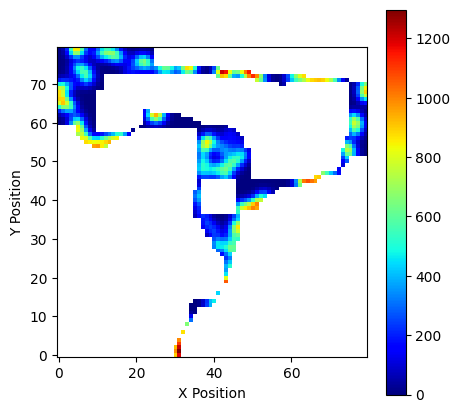

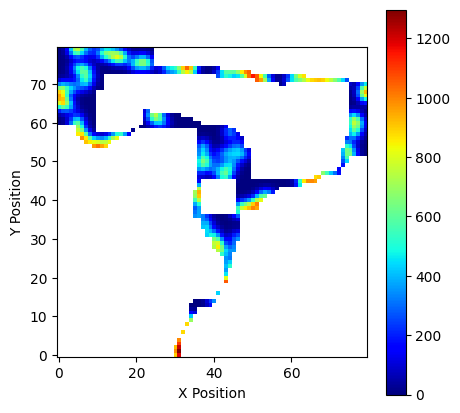

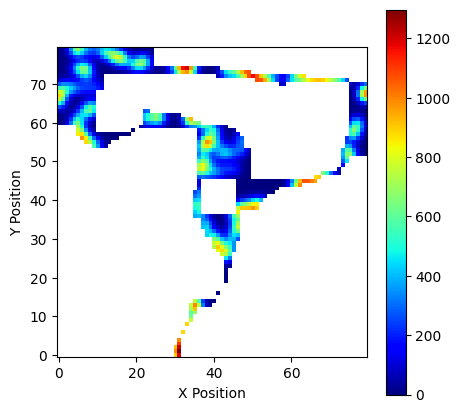

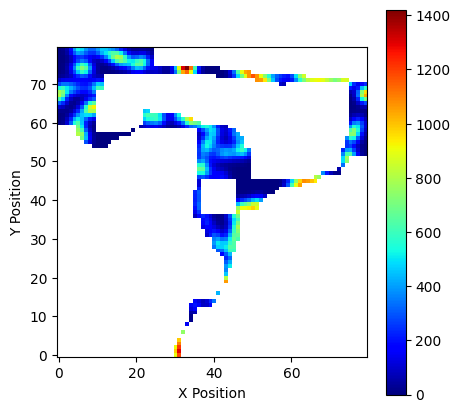

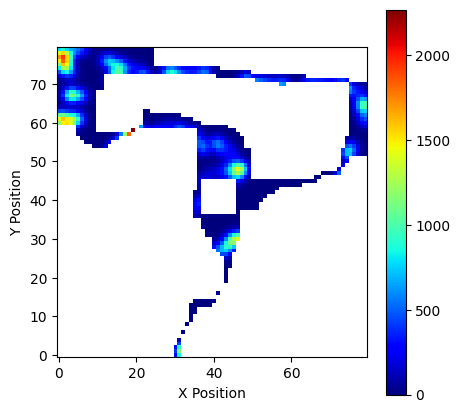

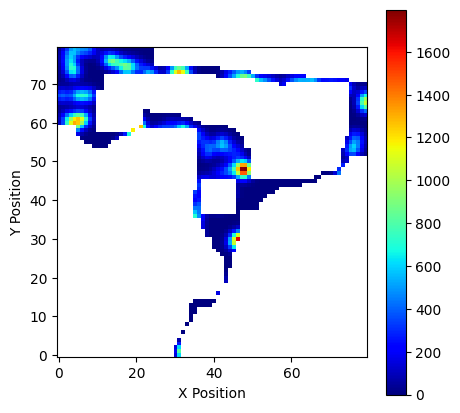

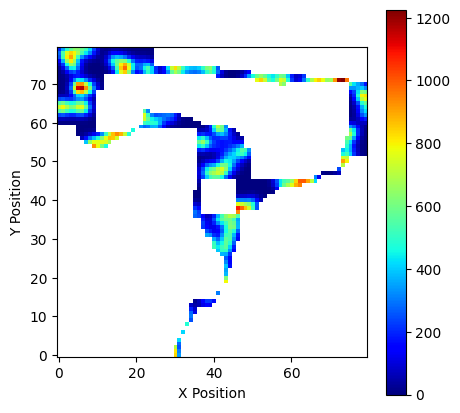

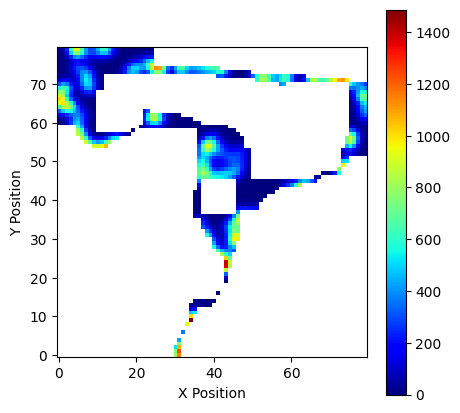

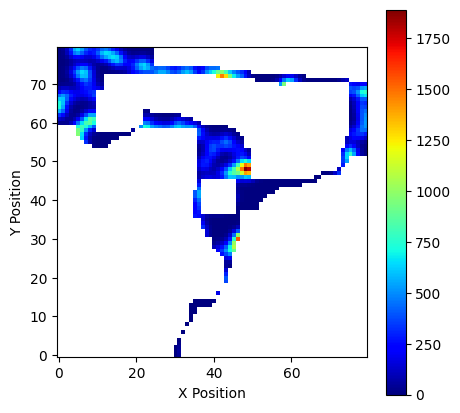

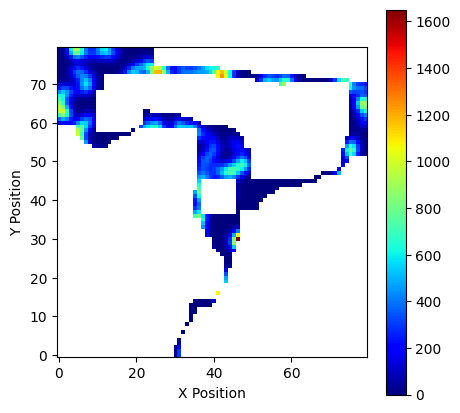

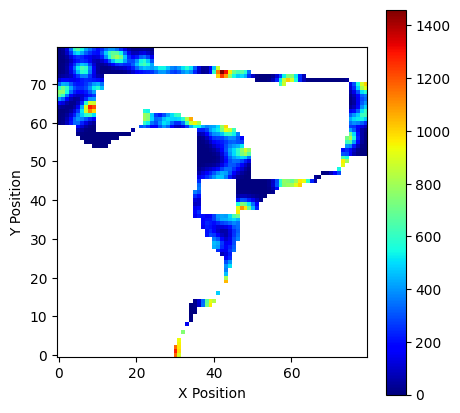

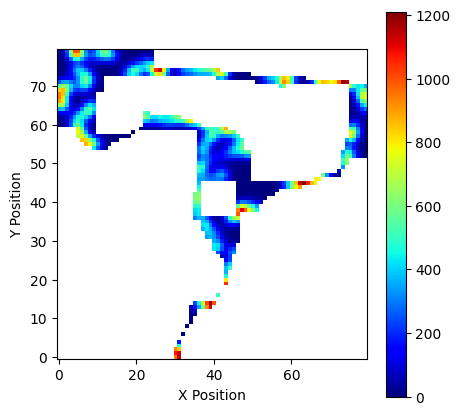

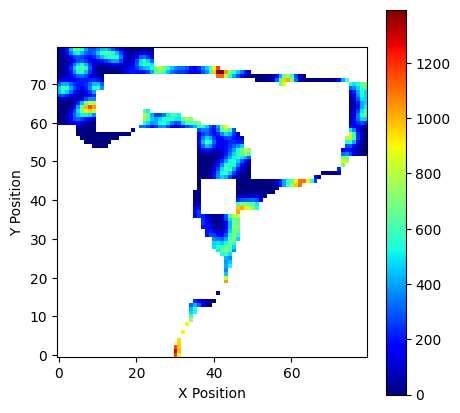

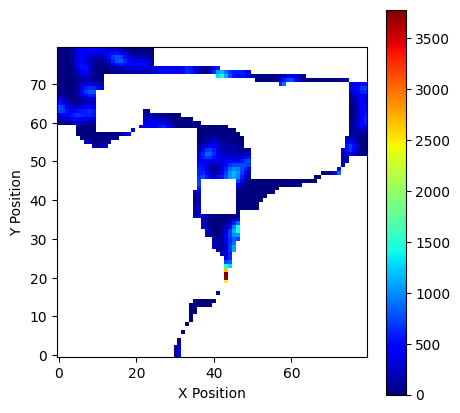

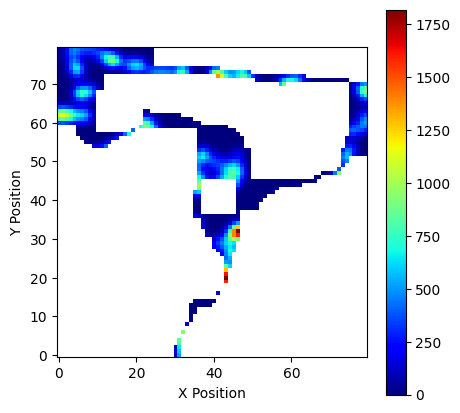

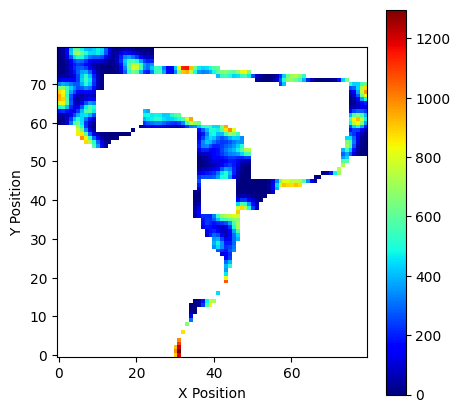

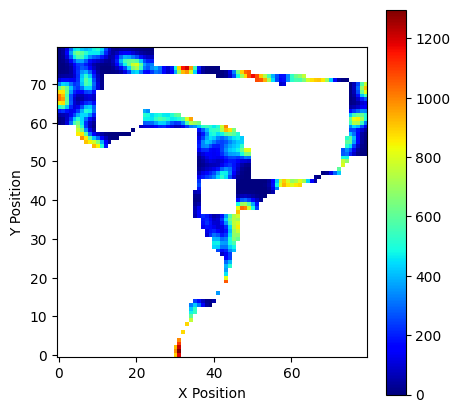

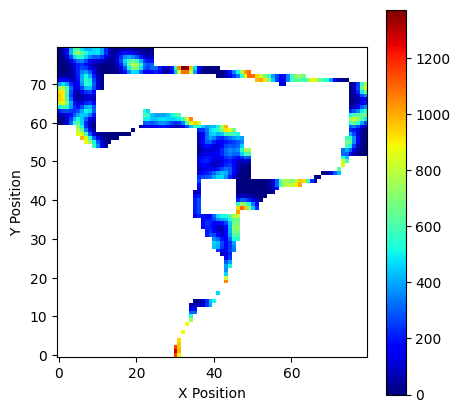

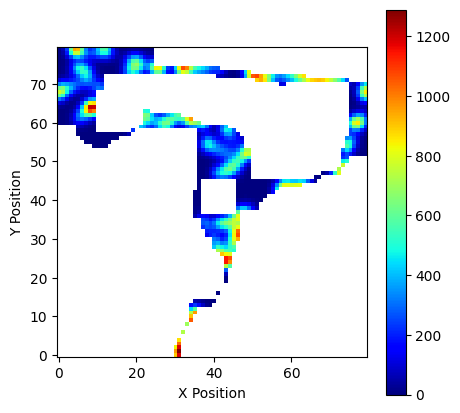

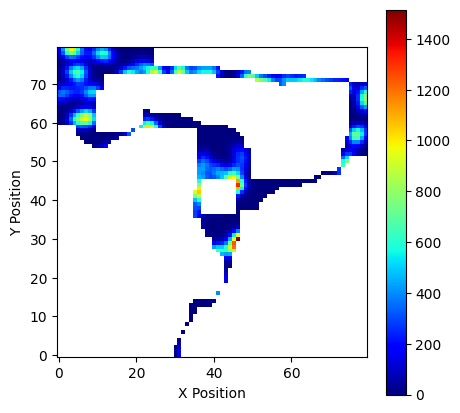

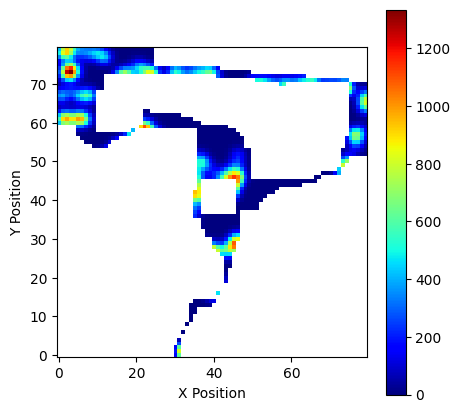

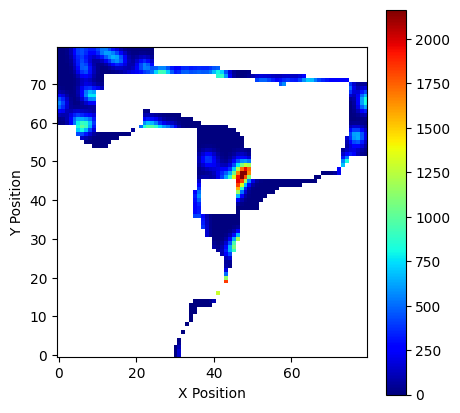

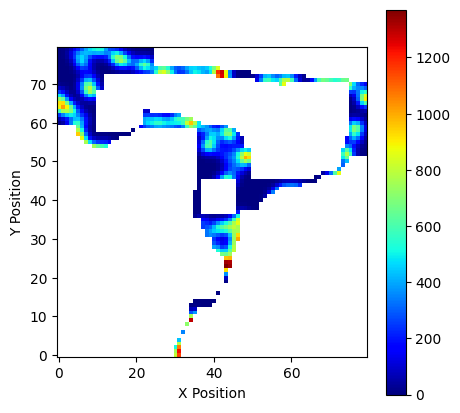

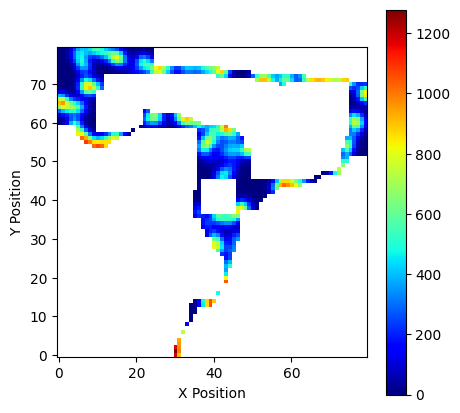

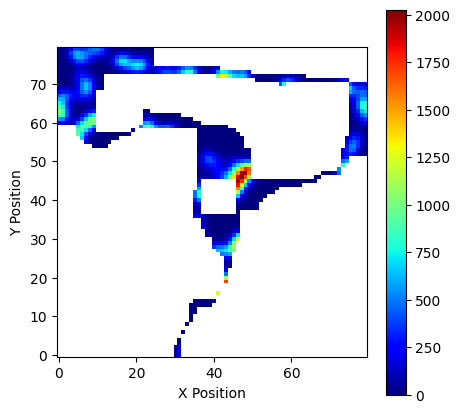

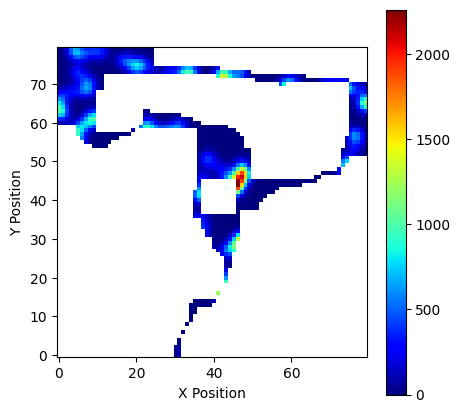

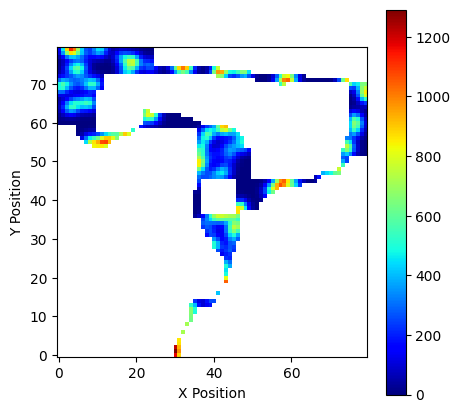

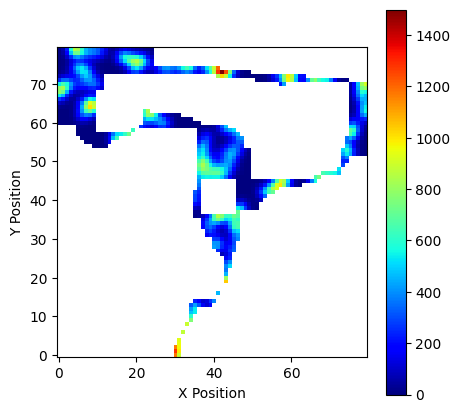

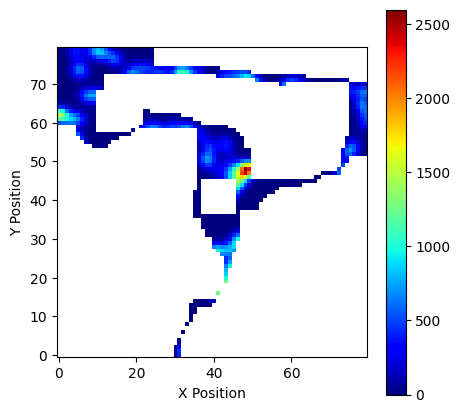

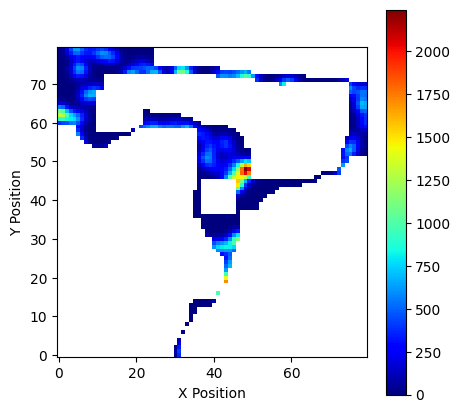

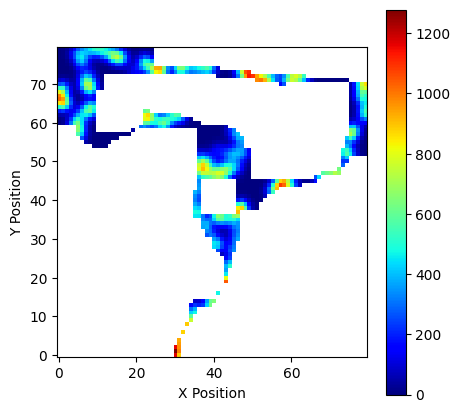

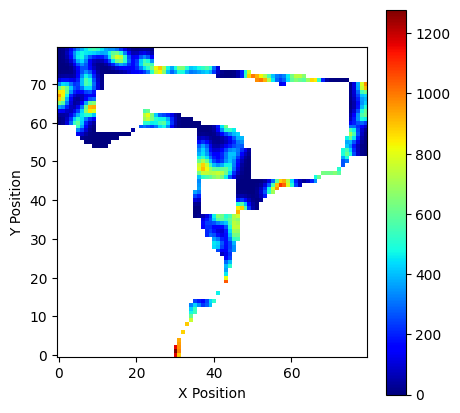

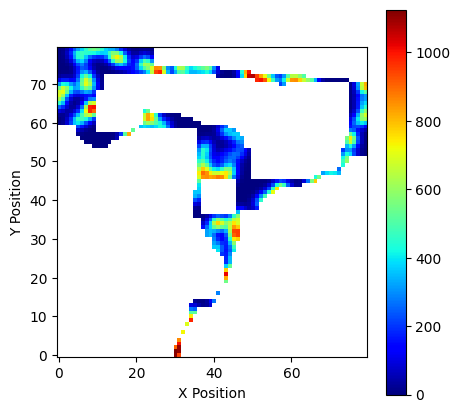

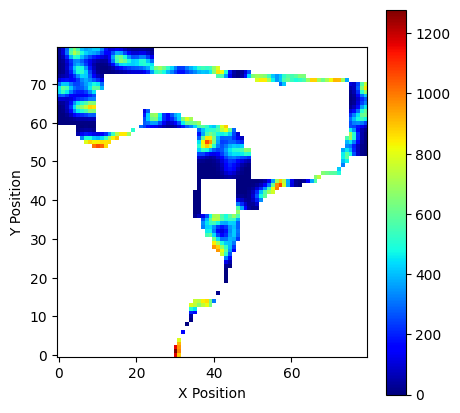

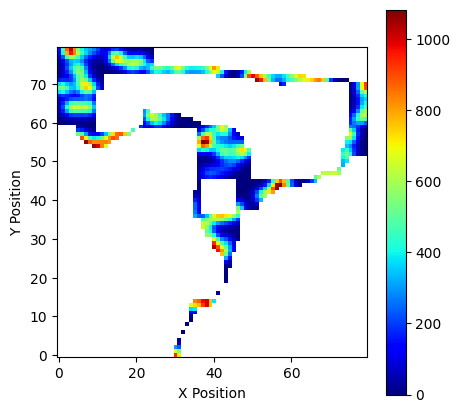

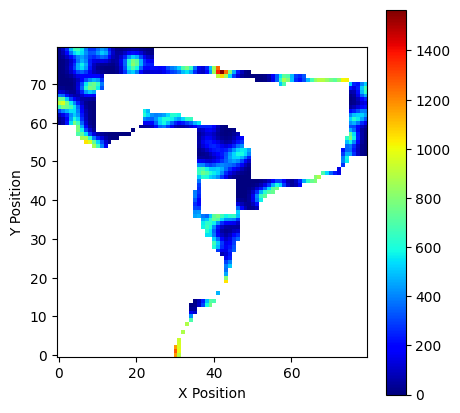

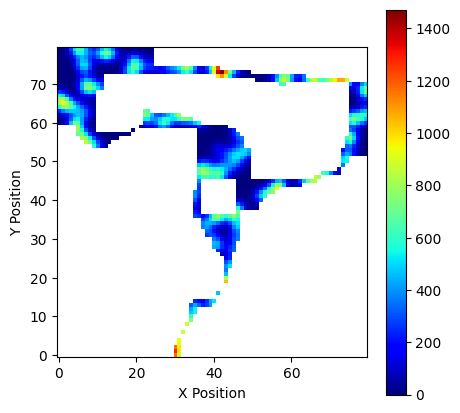

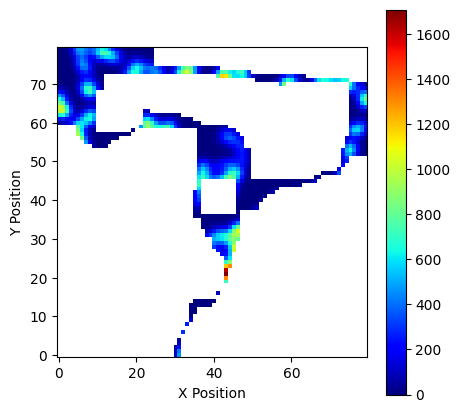

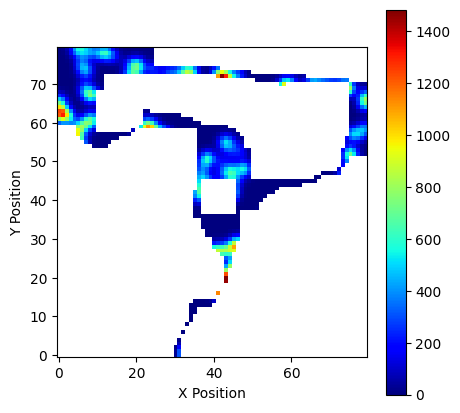

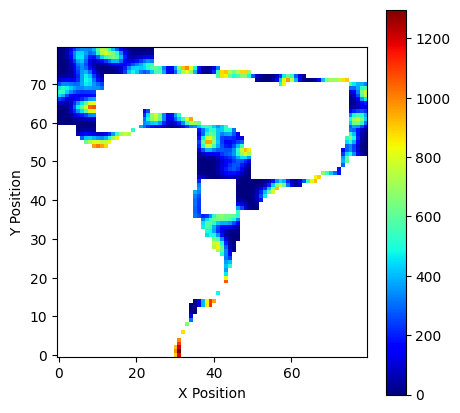

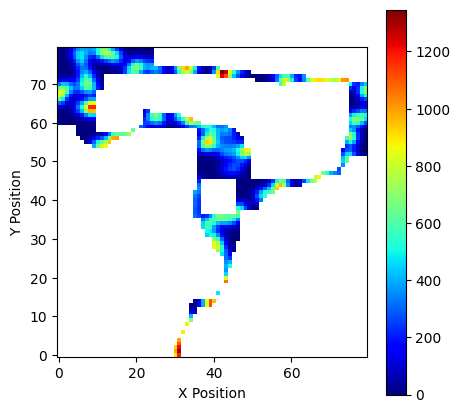

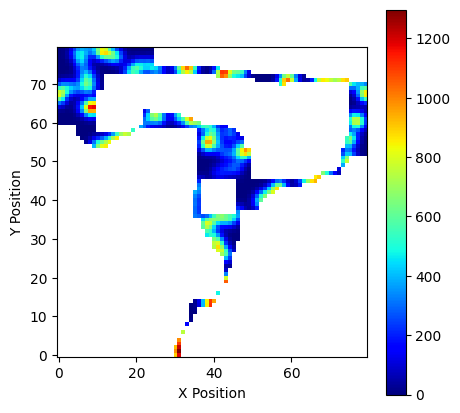

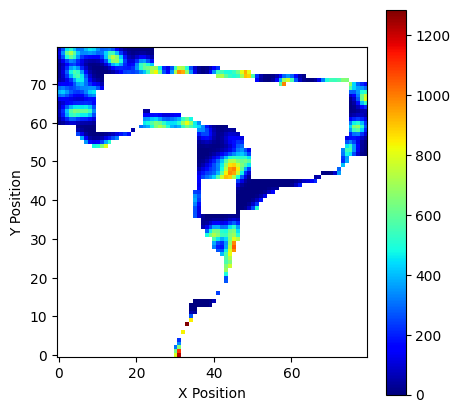

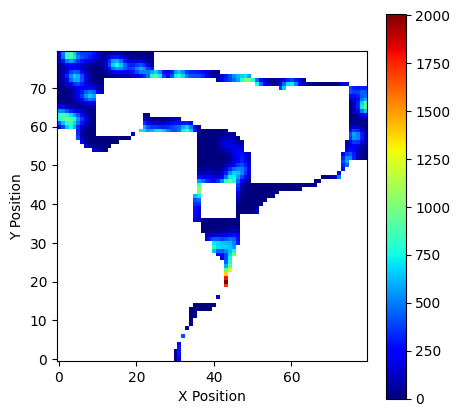

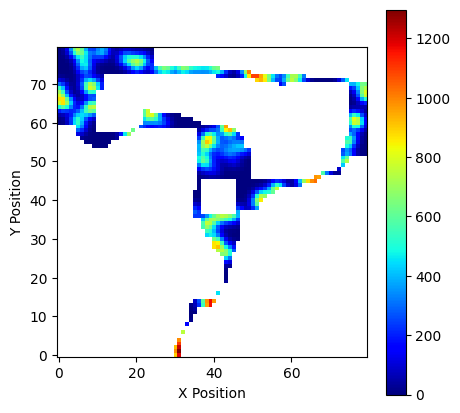

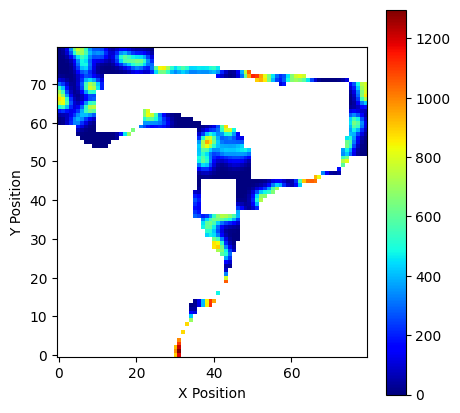

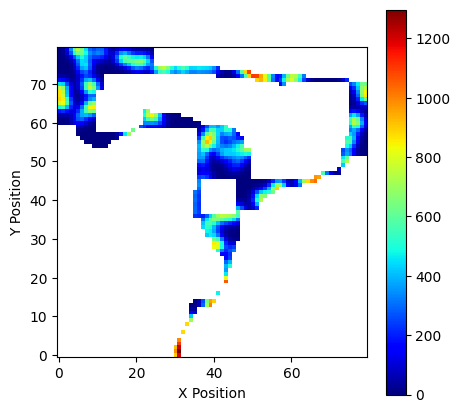

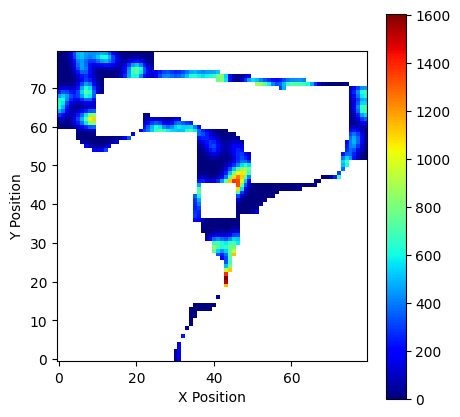

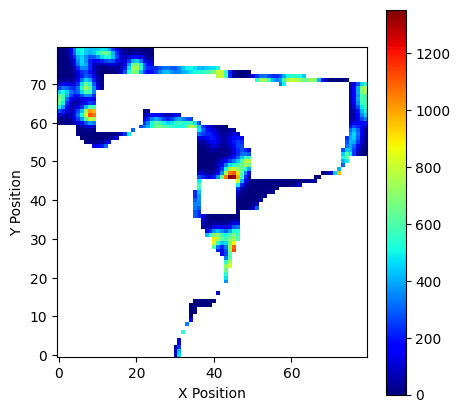

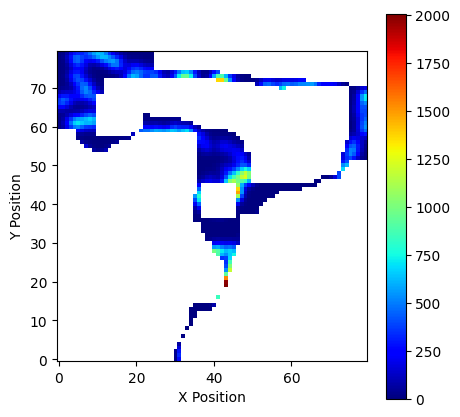

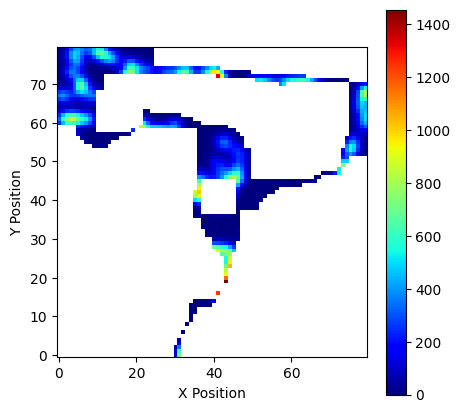

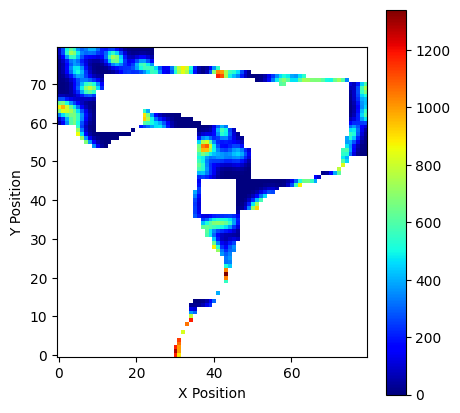

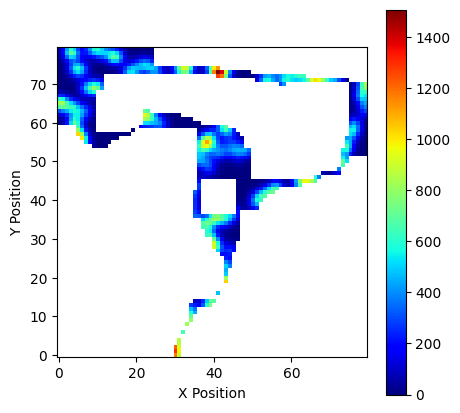

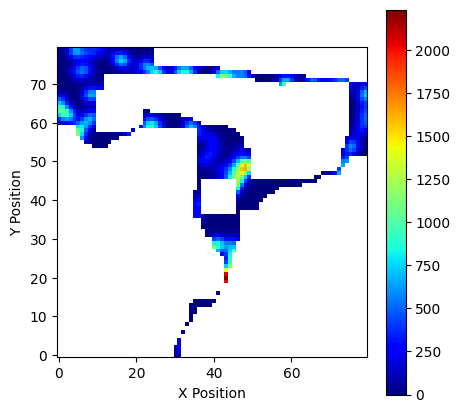

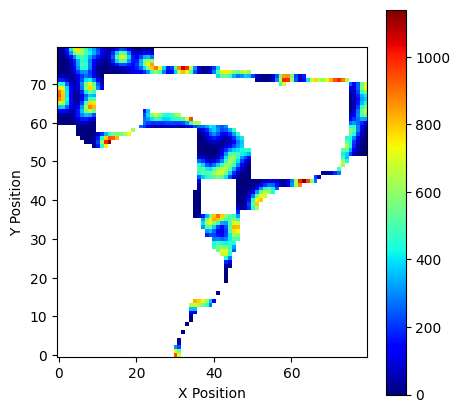

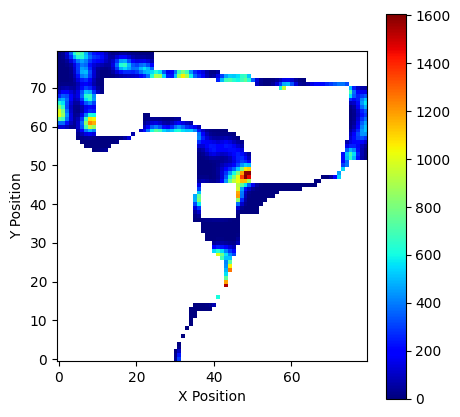

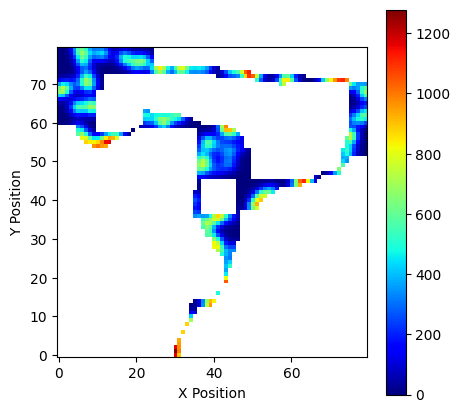

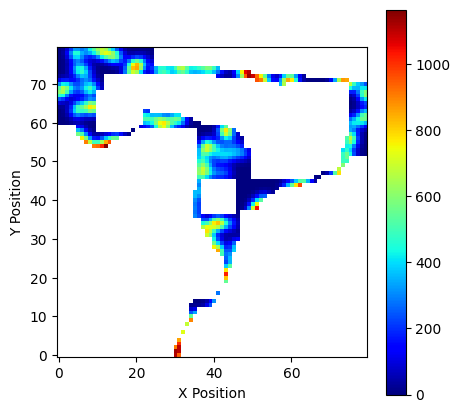

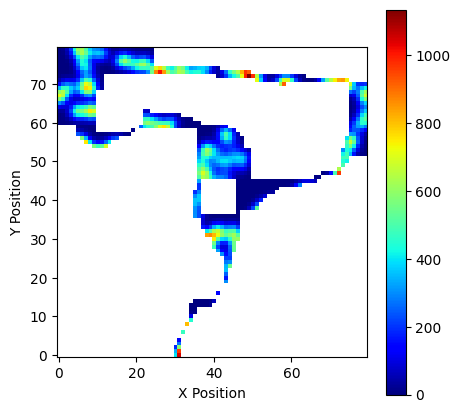

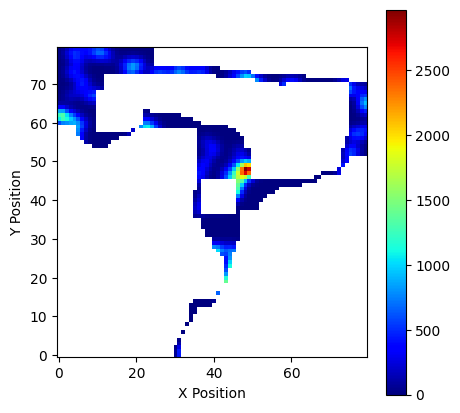

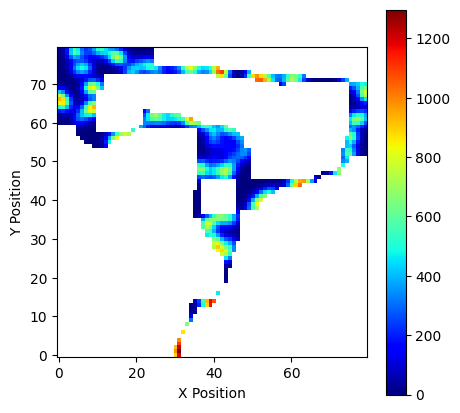

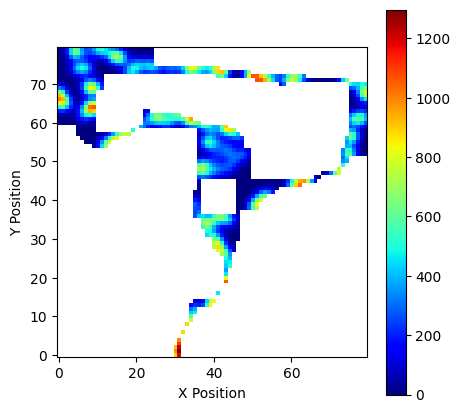

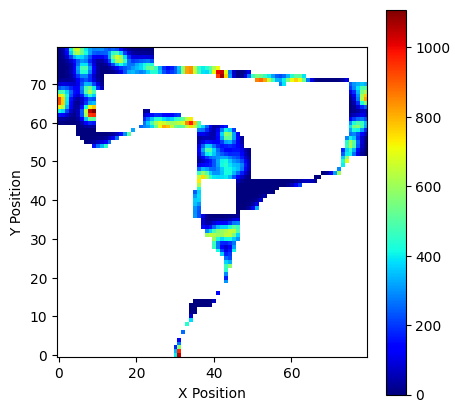

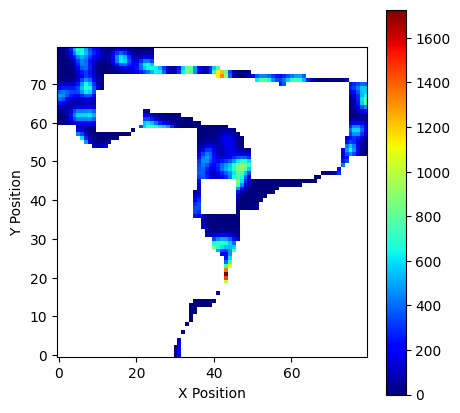

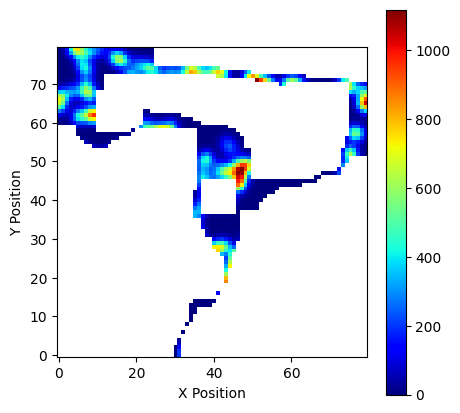

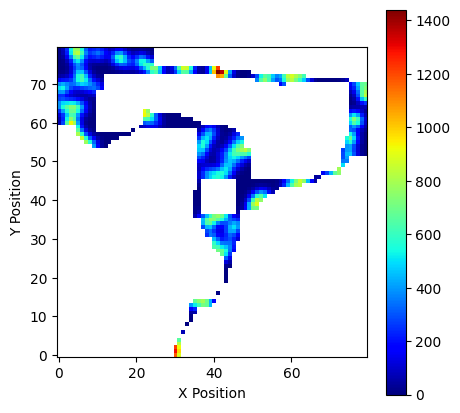

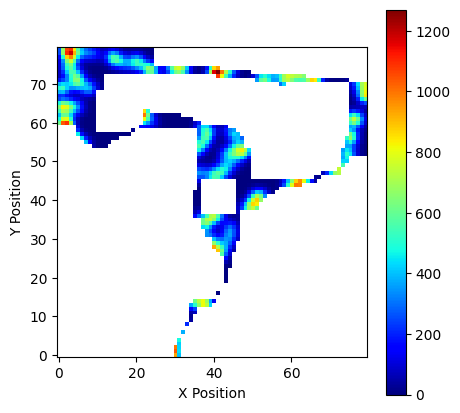

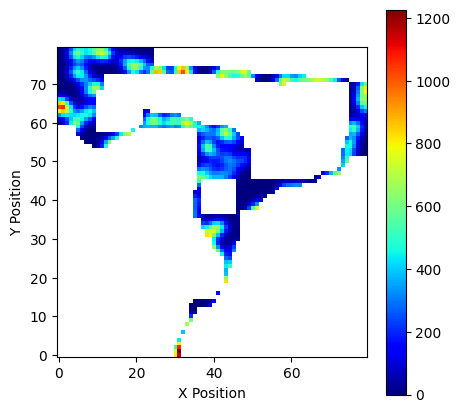

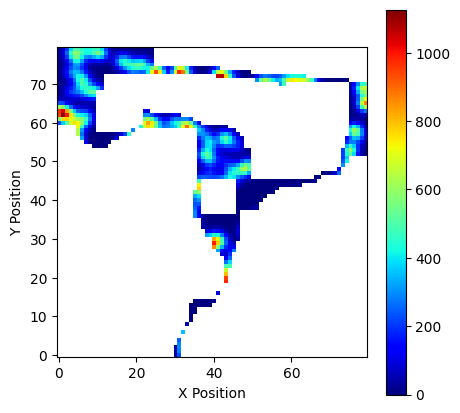

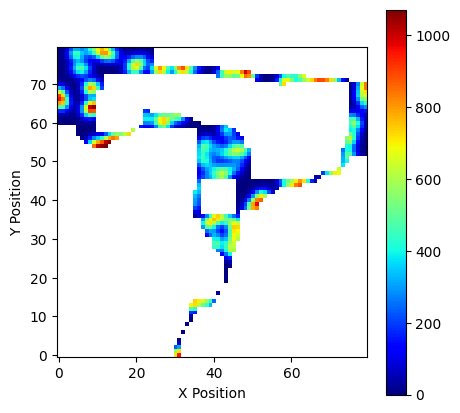

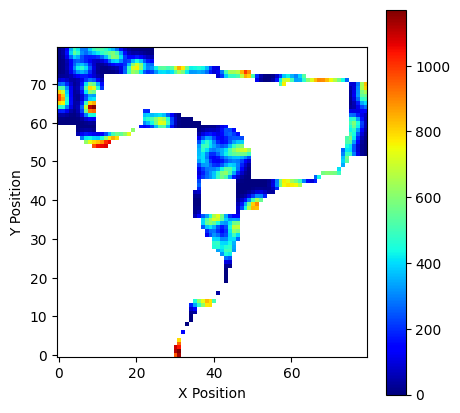

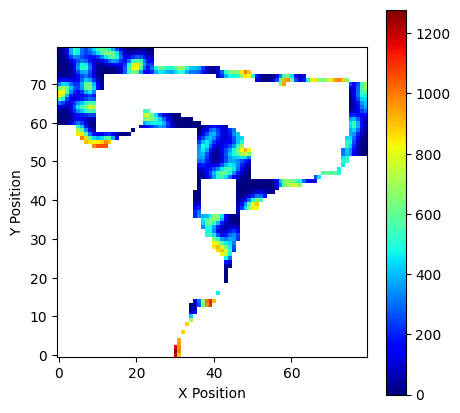

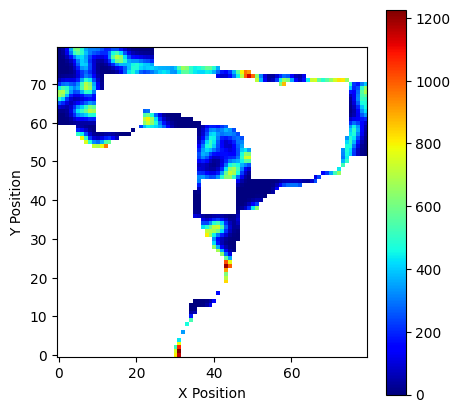

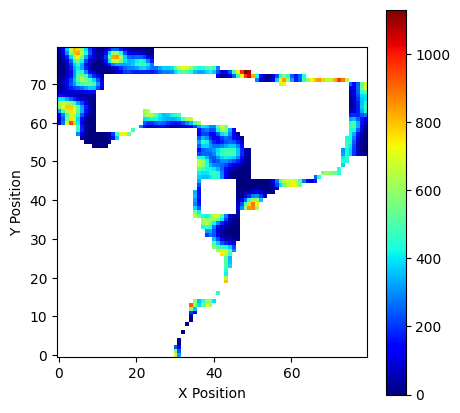

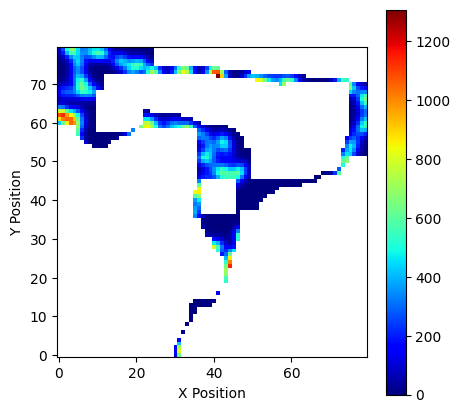

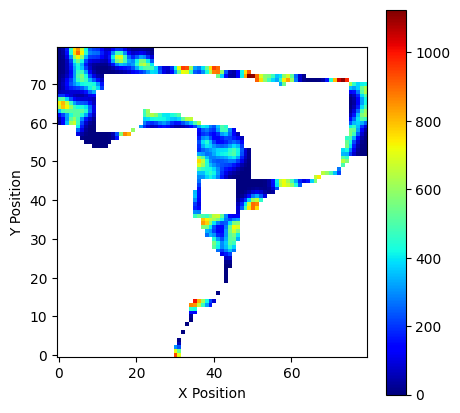

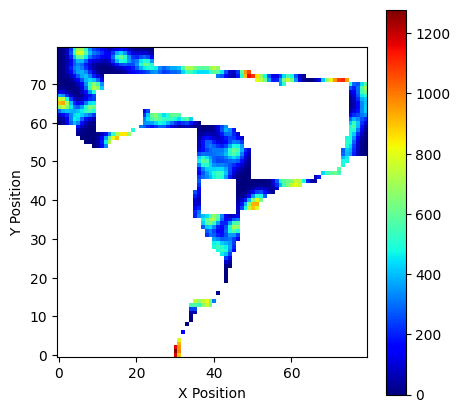

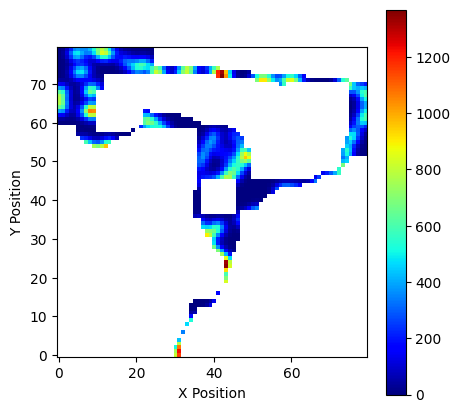

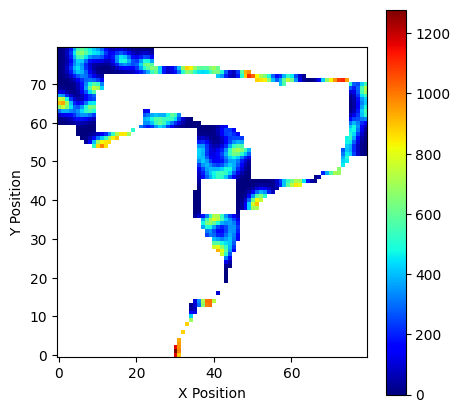

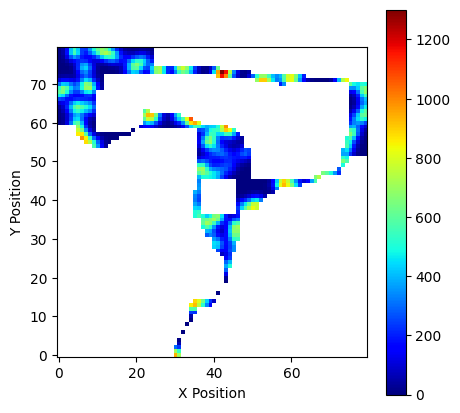

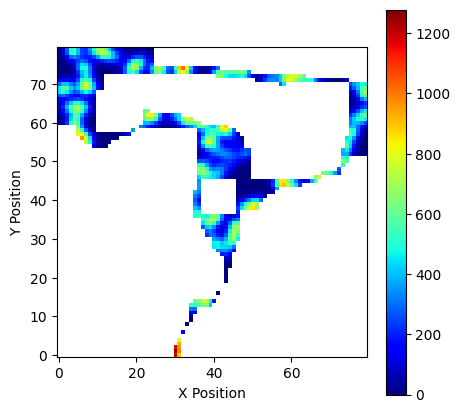

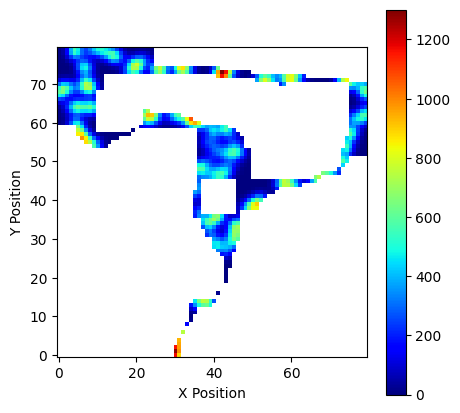

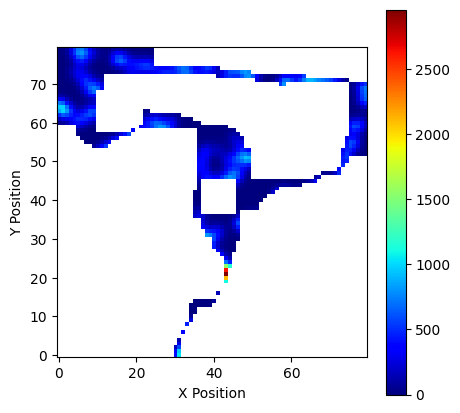

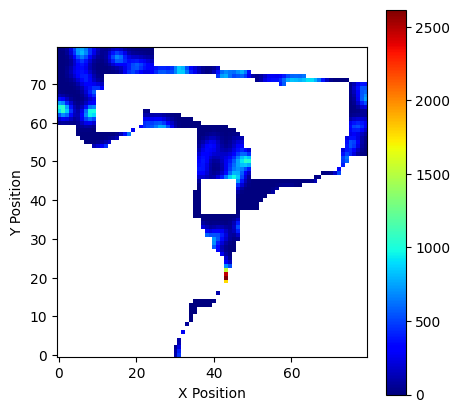

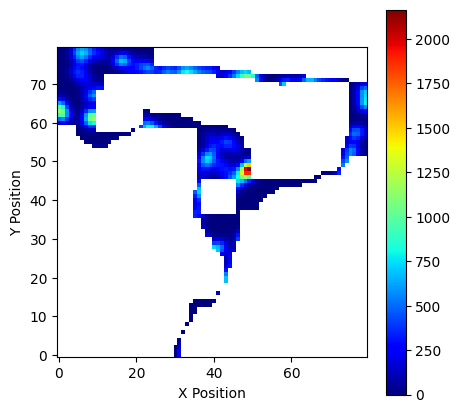

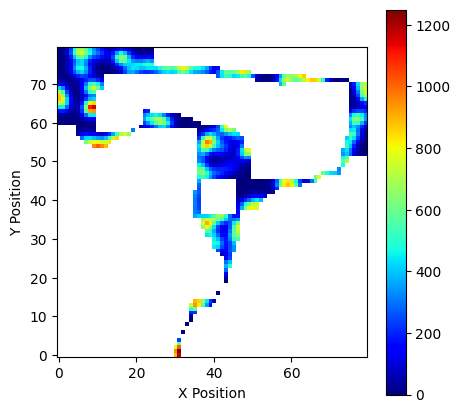

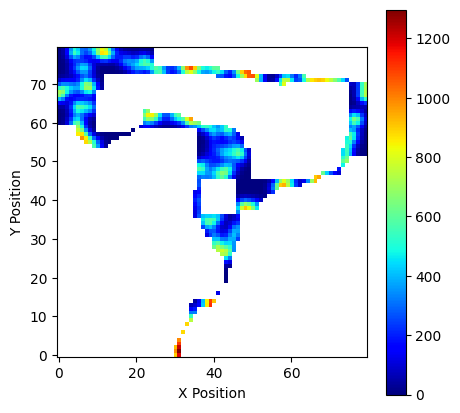

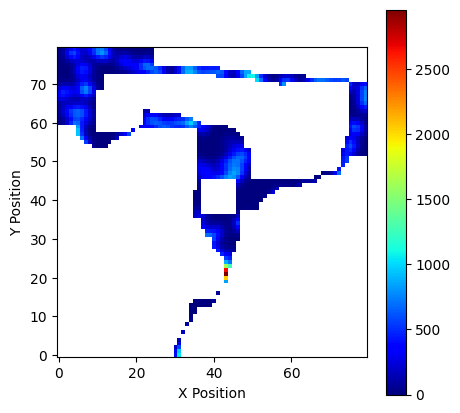

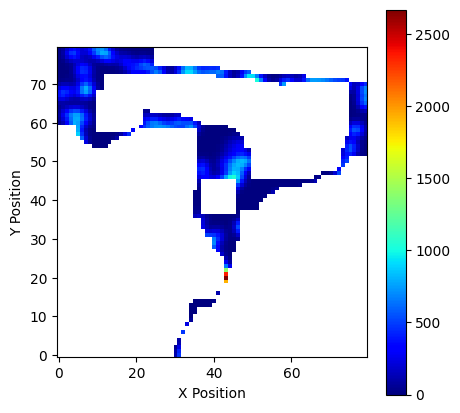

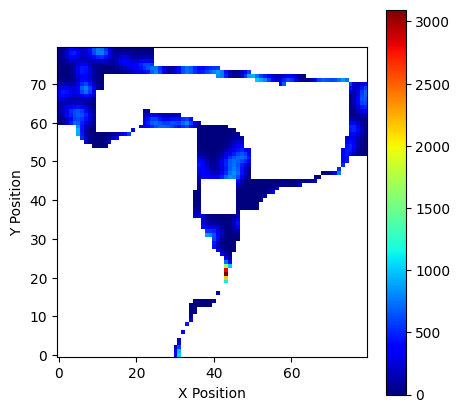

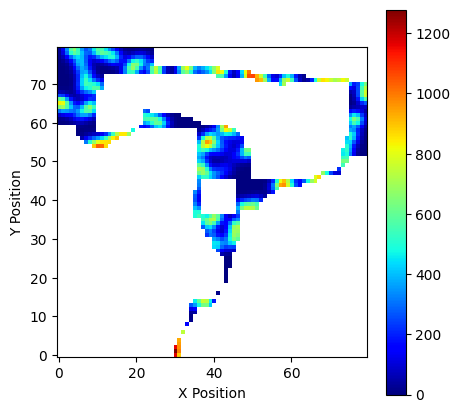

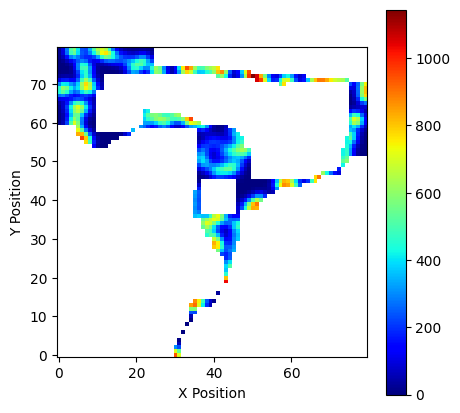

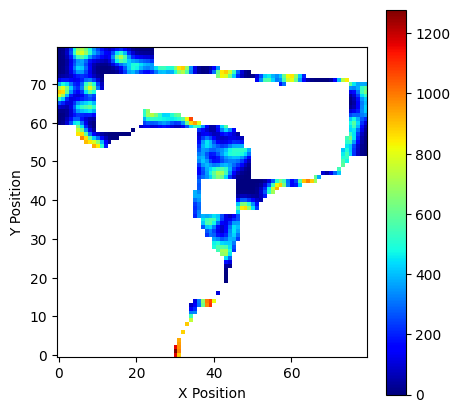

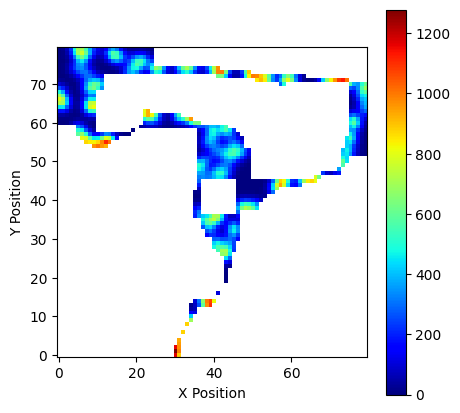

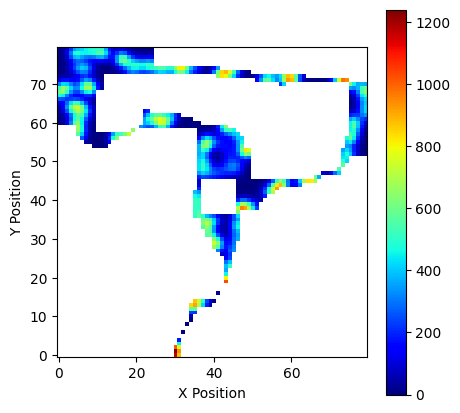

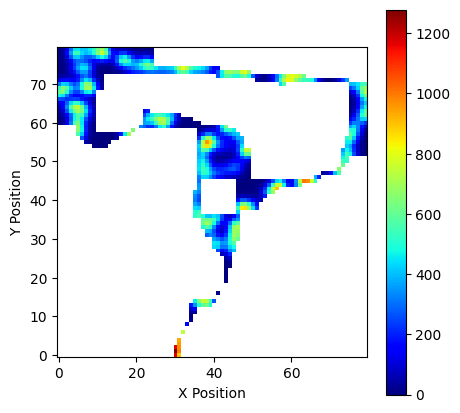

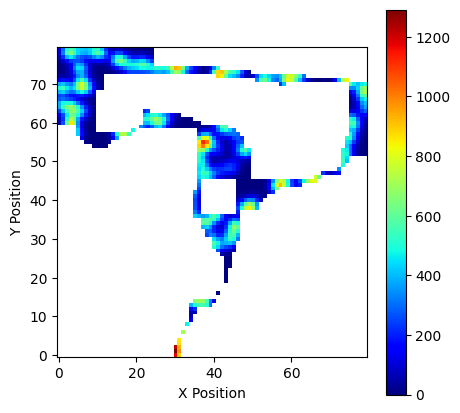

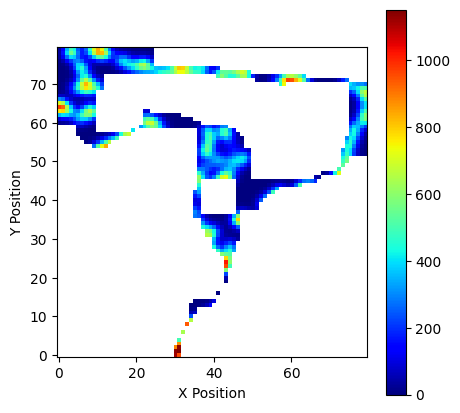

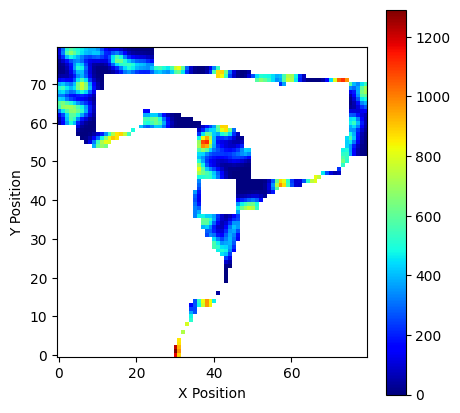

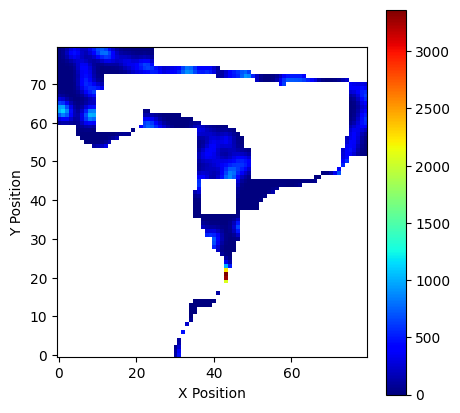

Firing-rate maps: (100, 80, 80)


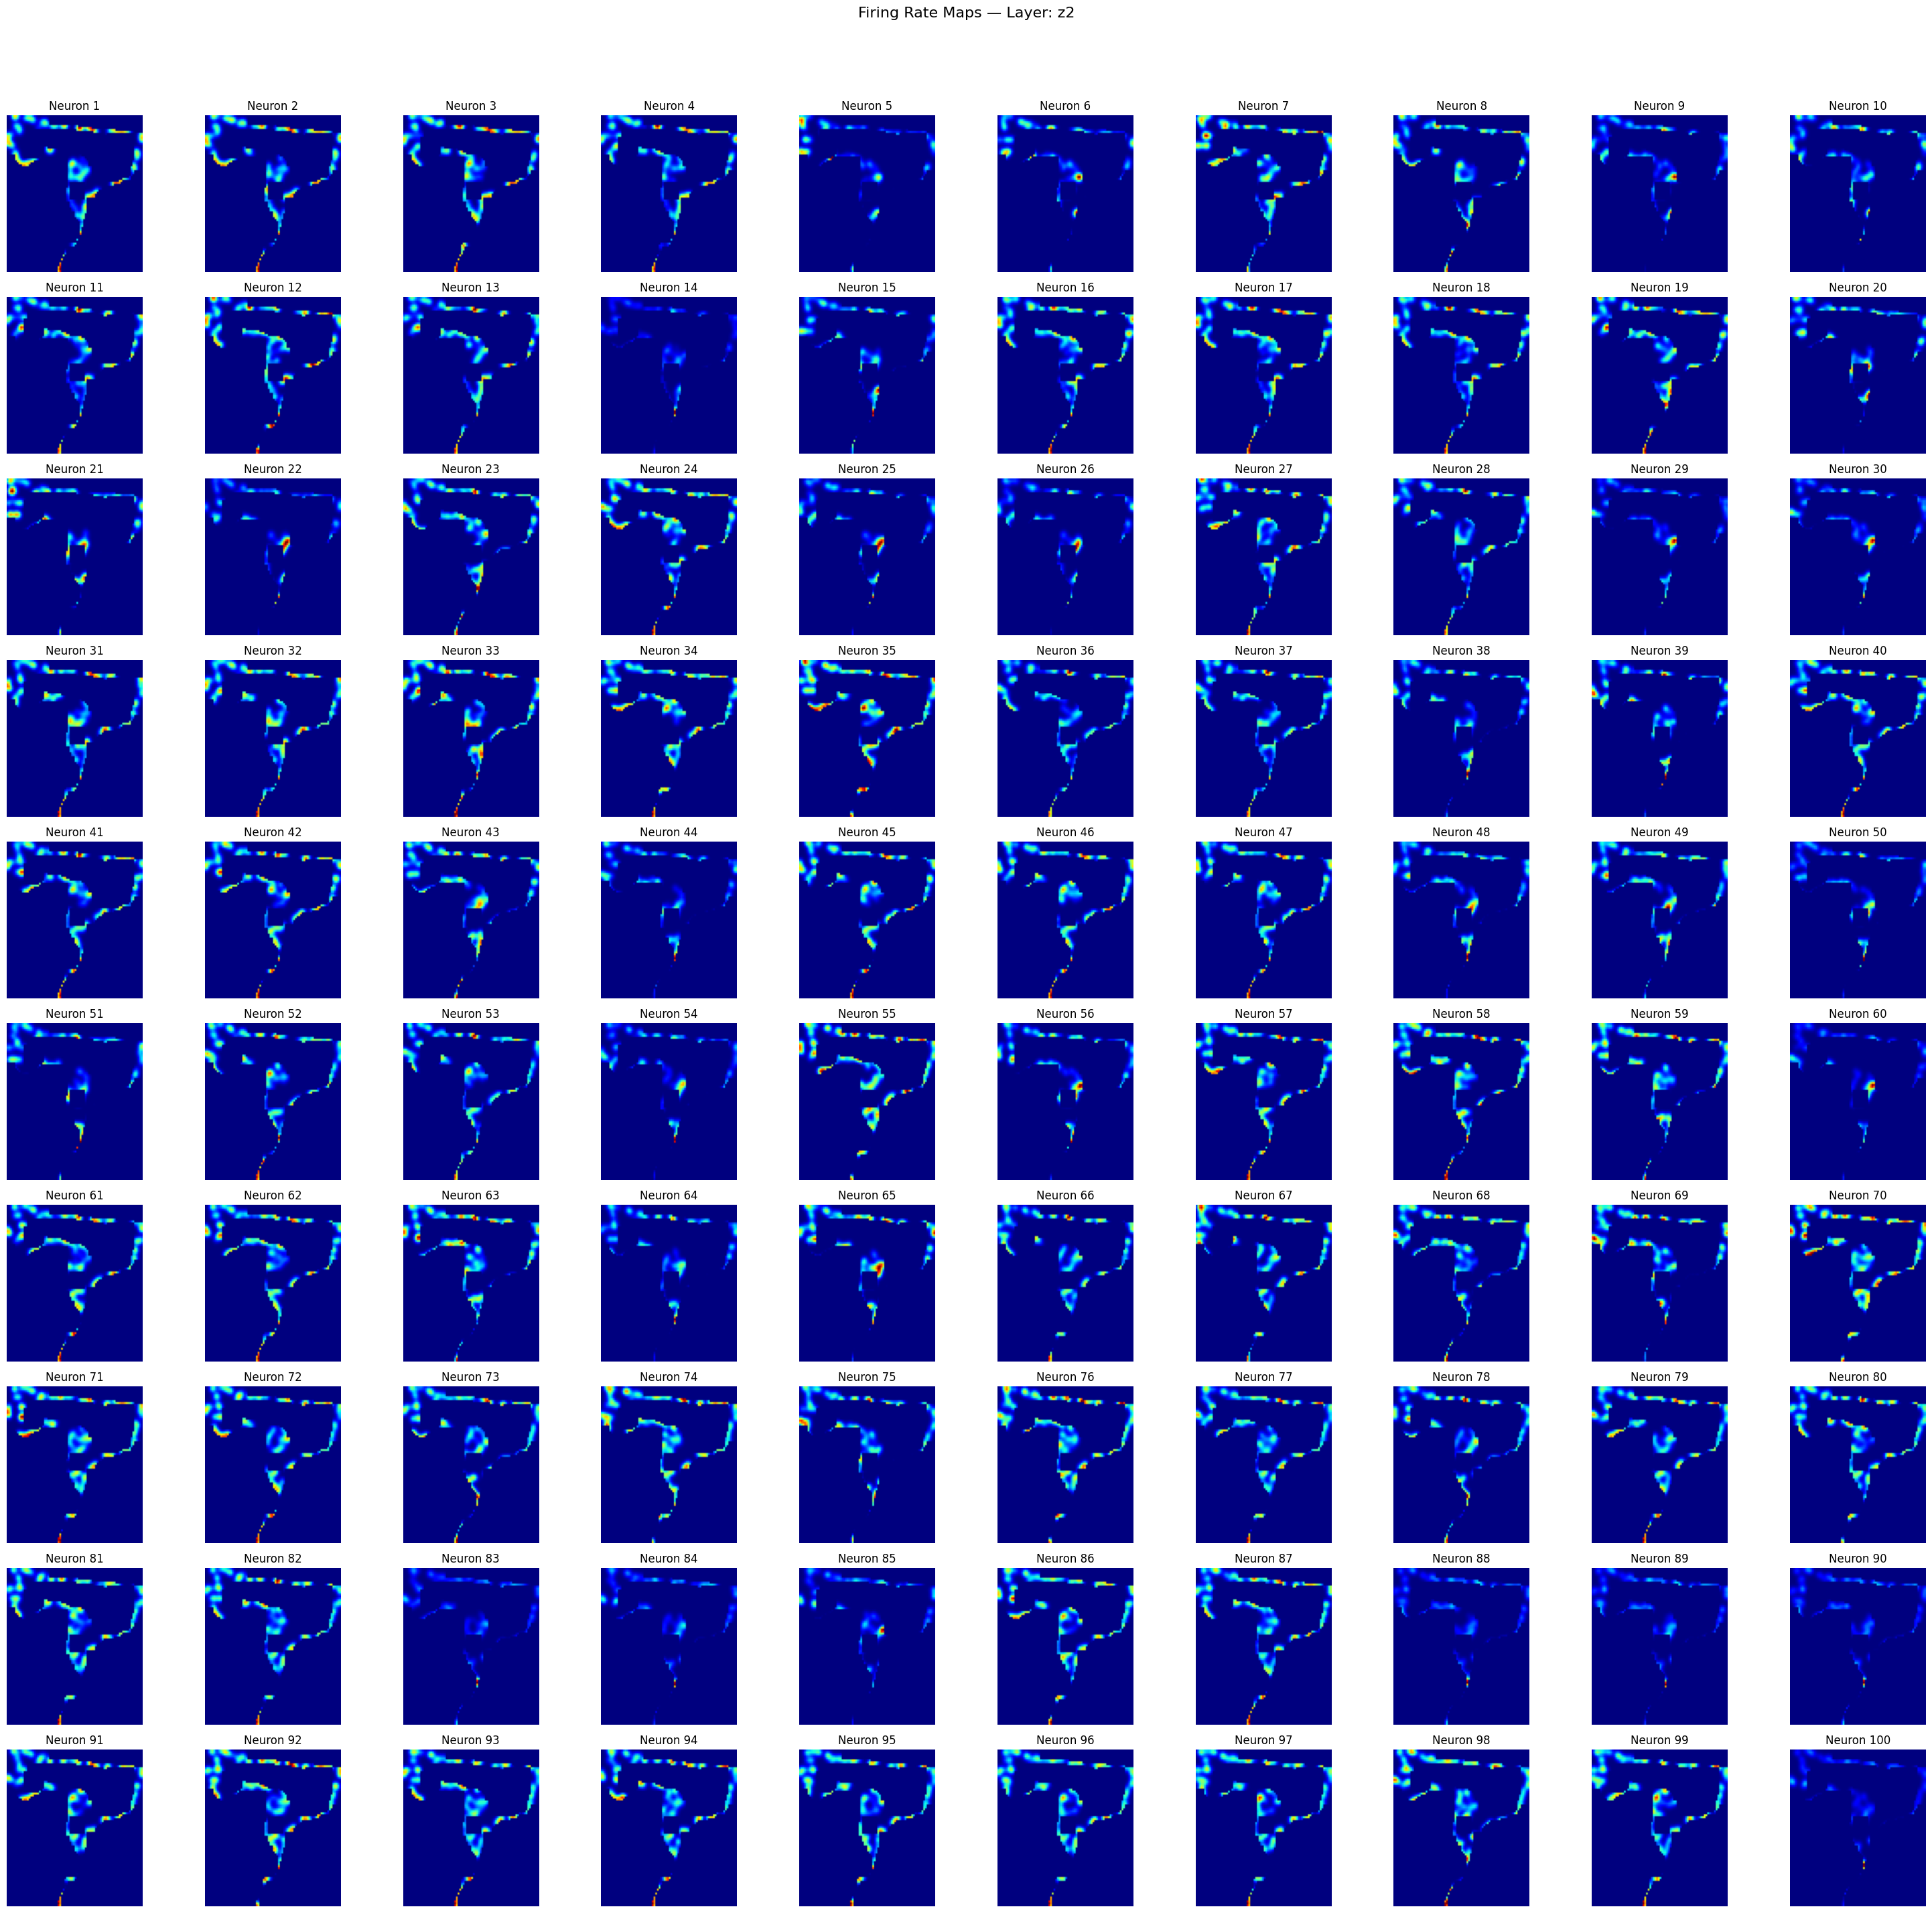

In [ ]:
# ============================================================
# Compute occupancy map
# ============================================================

occ_map, xedges, yedges = occupancy_map_func_2d(
    positions,
    reso=40
)

# ============================================================
# Compute firing-rate maps
# ============================================================

frm_list = []


    response = activations[:, neuron]

    frm_smooth, frm_norm, spike_map = firing_rate_map_2d(
        response,
        positions,
        occ_map,
        thresh_param=0.0,
        sub_plot=False
    )

    frm_list.append(frm_smooth)

frm_list = np.asarray(frm_list)

print("Firing-rate maps:", frm_list.shape)

# ============================================================
# Plot all neurons
# ============================================================

plot_frm_vs_position_2d(
    frm_list,
    positions,
    layer_name=layer_name,
    xedges=xedges,
    yedges=yedges
)